In [6]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import matplotlib.pyplot as plt

In [35]:
tickers = yf.Tickers('AAPL MSFT GOOG AMZN JPM')
 
data = yf.download(['AAPL', 'MSFT', 'GOOG', 'AMZN', 'JPM'], period='6mo',interval='1d')

C:\Users\manoj\AppData\Local\Temp\ipykernel_23812\1655980301.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(['AAPL', 'MSFT', 'GOOG', 'AMZN', 'JPM'], period='6mo',interval='1d')
[*********************100%***********************]  5 of 5 completed


In [36]:
print(data.head())
print(data.columns)


Price            Close                                                  \
Ticker            AAPL        AMZN        GOOG         JPM        MSFT   
Date                                                                     
2025-02-11  232.315353  232.759995  186.632797  271.996185  409.864197   
2025-02-12  236.559784  228.929993  184.996613  272.451202  407.473389   
2025-02-13  241.213684  230.369995  187.440887  273.311707  408.967651   
2025-02-14  244.279663  228.679993  186.433258  273.578766  406.865723   
2025-02-18  244.149841  226.649994  185.365753  276.902191  408.071106   

Price             High                                                  ...  \
Ticker            AAPL        AMZN        GOOG         JPM        MSFT  ...   
Date                                                                    ...   
2025-02-11  234.921936  233.440002  188.358750  273.212805  410.910163  ...   
2025-02-12  236.649678  231.179993  186.393350  273.440315  409.176831  ...   
2025-02-13  

In [37]:
data

Price            Close                                                  \
Ticker            AAPL        AMZN        GOOG         JPM        MSFT   
Date                                                                     
2025-02-11  232.315353  232.759995  186.632797  271.996185  409.864197   
2025-02-12  236.559784  228.929993  184.996613  272.451202  407.473389   
2025-02-13  241.213684  230.369995  187.440887  273.311707  408.967651   
2025-02-14  244.279663  228.679993  186.433258  273.578766  406.865723   
2025-02-18  244.149841  226.649994  185.365753  276.902191  408.071106   
...                ...         ...         ...         ...         ...   
2025-08-05  202.919998  213.750000  195.320007  291.369995  527.750000   
2025-08-06  213.250000  222.309998  196.919998  291.350006  524.940002   
2025-08-07  220.029999  223.130005  197.279999  286.940002  520.840027   
2025-08-08  229.350006  222.690002  202.089996  288.760010  522.039978   
2025-08-11  227.414993  220.795395  201.585007  289.440002  521.782227   

Price             High                                                  ...  \
Ticker            AAPL        AMZN        GOOG         JPM        MSFT  ...   
Date                                                                    ...   
2025-02-11  234.921936  233.440002  188.358750  273.212805  410.910163  ...   
2025-02-12  236.649678  231.179993  186.393350  273.440315  409.176831  ...   
2025-02-13  242.022621  230.419998  187.550631  273.954624  409.425881  ...   
2025-02-14  245.228416  229.889999  187.710265  276.190039  407.343895  ...   
2025-02-18  244.858903  229.300003  187.341121  276.921963  409.027421  ...   
...                ...         ...         ...         ...         ...  ...   
2025-08-05  205.339996  216.300003  198.699997  295.790009  537.299988  ...   
2025-08-06  215.380005  222.649994  197.380005  293.290009  531.700012  ...   
2025-08-07  220.850006  226.220001  198.369995  293.459991  528.090027  ...   
2025-08-08  231.000000  223.800003  203.429993  291.230011  524.659973  ...   
2025-08-11  229.559998  223.050003  202.160004  291.320007  527.549988  ...   

Price             Open                                                  \
Ticker            AAPL        AMZN        GOOG         JPM        MSFT   
Date                                                                     
2025-02-11  227.901144  231.919998  186.398346  267.317700  408.071103   
2025-02-12  230.897211  230.460007  184.797083  271.096092  405.650381   
2025-02-13  236.599739  228.850006  185.495433  272.500627  405.441201   
2025-02-14  240.934044  229.199997  186.393358  274.350273  406.228190   
2025-02-18  243.830253  228.820007  187.001920  273.746918  406.437373   
...                ...         ...         ...         ...         ...   
2025-08-05  203.399994  213.050003  195.544998  294.690002  537.179993   
2025-08-06  205.630005  214.699997  195.250000  292.299988  530.900024   
2025-08-07  218.880005  221.000000  197.710007  292.940002  526.799988   
2025-08-08  220.830002  223.139999  197.979996  288.980011  522.599976   
2025-08-11  227.919998  222.000000  201.554993  289.399994  522.460022   

Price          Volume                                         
Ticker           AAPL      AMZN      GOOG      JPM      MSFT  
Date                                                          
2025-02-11   53718400  23713700  13028100  7196400  18140600  
2025-02-12   45243300  32285200  17632300  6683900  19121700  
2025-02-13   53614100  31346500  12729300  8398700  23891700  
2025-02-14   40896200  27031100  12714200  5688600  22758500  
2025-02-18   48822500  42975100  19796000  7919800  21423100  
...               ...       ...       ...      ...       ...  
2025-08-05   44155100  51505100  19010200  7182300  19171600  
2025-08-06  108483100  54823000  15383700  6330200  21355700  
2025-08-07   90224800  40603500  14660600  8057100  16079100  
2025-08-08  113696100  32916900  24356300  6634100  15516600  


#Historical data for the past 6 month has been collected for these companies using yfinance. 
#AAPL   -  Apple Inc.                   |
#MSFT   -  Microsoft Corp               
#GOOG  -  Alphabet Inc (Google Class C)  
#AMZN   - Amazon.com Inc               
#JPM     JMorgan Chase & Co   

In [2]:
!pip install yfinance


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     ------------------------------------- 949.2/949.2 kB 22.2 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 43.5 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15617 sha256=6d4a36bfdcdc64b2bc8e55d482cfc319de6d8009a8651866cfb7ccae57f384e7
  Stored in directory: c:\users\manoj\appdata\local\pip\cache\wheels\cc\bd\6f\664d62c99327abeef7d86489e663

In [18]:
# checking for the missing values in the data
for sym, df in data.items():
    print(sym, "missing values:\n", df.isna().sum())


('Close', 'AAPL') missing values:
 0
('Close', 'GOOG') missing values:
 0
('Close', 'MSFT') missing values:
 0
('High', 'AAPL') missing values:
 0
('High', 'GOOG') missing values:
 0
('High', 'MSFT') missing values:
 0
('Low', 'AAPL') missing values:
 0
('Low', 'GOOG') missing values:
 0
('Low', 'MSFT') missing values:
 0
('Open', 'AAPL') missing values:
 0
('Open', 'GOOG') missing values:
 0
('Open', 'MSFT') missing values:
 0
('Volume', 'AAPL') missing values:
 0
('Volume', 'GOOG') missing values:
 0
('Volume', 'MSFT') missing values:
 0


In [19]:
import numpy as np
for sym, df in data.items():
    # Replace infinities with NaN if its found in the data 
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    # Drop rows with any missing values
    df.dropna(inplace=True)      
    # Remove exact duplicate rows, if any have found in the data we have taken from the yfinance 
    df.drop_duplicates(inplace=True)
    data[sym] = df


In [ ]:
# calculating any anomalies in the above fetched data for past 6 months
for sym, df in data.items():
    anomalies = df[(df['Close'] < 0) | (df['Volume'] < 0)]
    print(sym, "anomalous entries:\n", anomalies)


AAPL anomalous entries:
 Price      Close High  Low Open Volume
Ticker      AAPL AAPL AAPL AAPL   AAPL
Date                                  
2025-01-21   NaN  NaN  NaN  NaN    NaN
2025-01-22   NaN  NaN  NaN  NaN    NaN
2025-01-23   NaN  NaN  NaN  NaN    NaN
2025-01-24   NaN  NaN  NaN  NaN    NaN
2025-01-27   NaN  NaN  NaN  NaN    NaN
...          ...  ...  ...  ...    ...
2025-07-14   NaN  NaN  NaN  NaN    NaN
2025-07-15   NaN  NaN  NaN  NaN    NaN
2025-07-16   NaN  NaN  NaN  NaN    NaN
2025-07-17   NaN  NaN  NaN  NaN    NaN
2025-07-18   NaN  NaN  NaN  NaN    NaN

[124 rows x 5 columns]
MSFT anomalous entries:
 Price      Close High  Low Open Volume
Ticker      MSFT MSFT MSFT MSFT   MSFT
Date                                  
2025-01-21   NaN  NaN  NaN  NaN    NaN
2025-01-22   NaN  NaN  NaN  NaN    NaN
2025-01-23   NaN  NaN  NaN  NaN    NaN
2025-01-24   NaN  NaN  NaN  NaN    NaN
2025-01-27   NaN  NaN  NaN  NaN    NaN
...          ...  ...  ...  ...    ...
2025-07-14   NaN  NaN  NaN  N

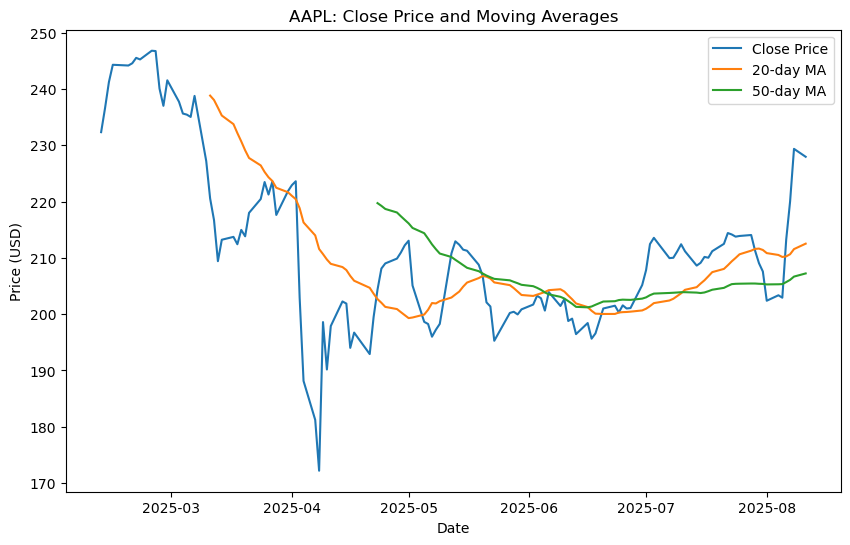

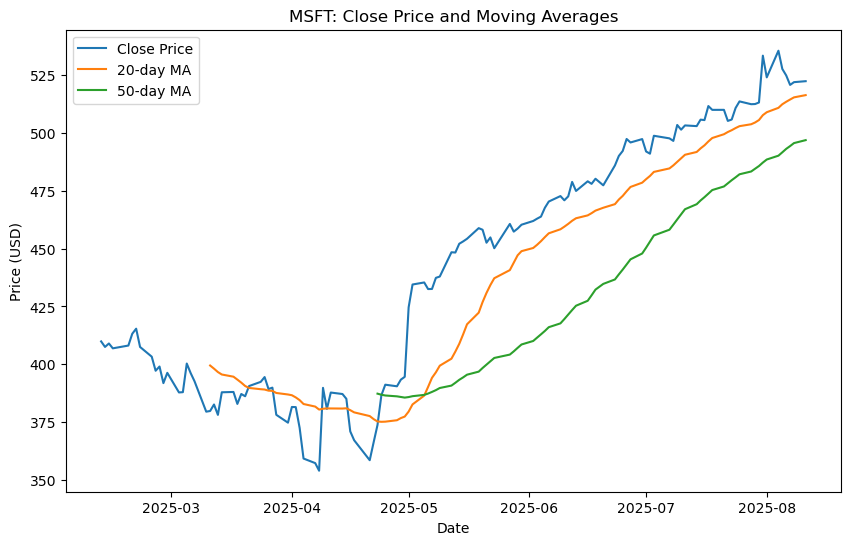

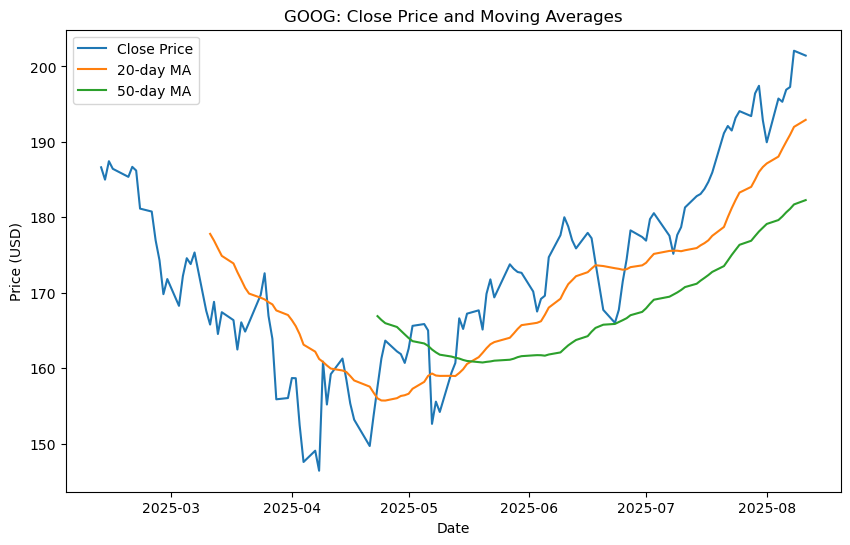

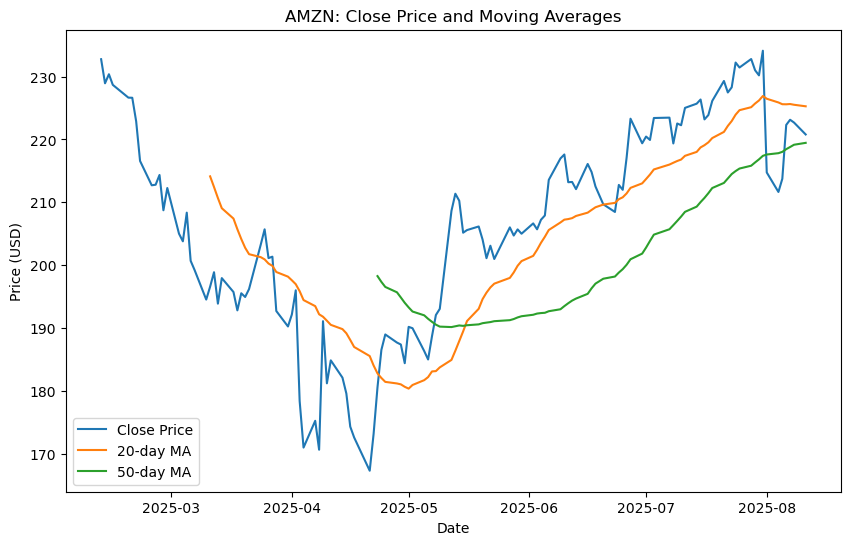

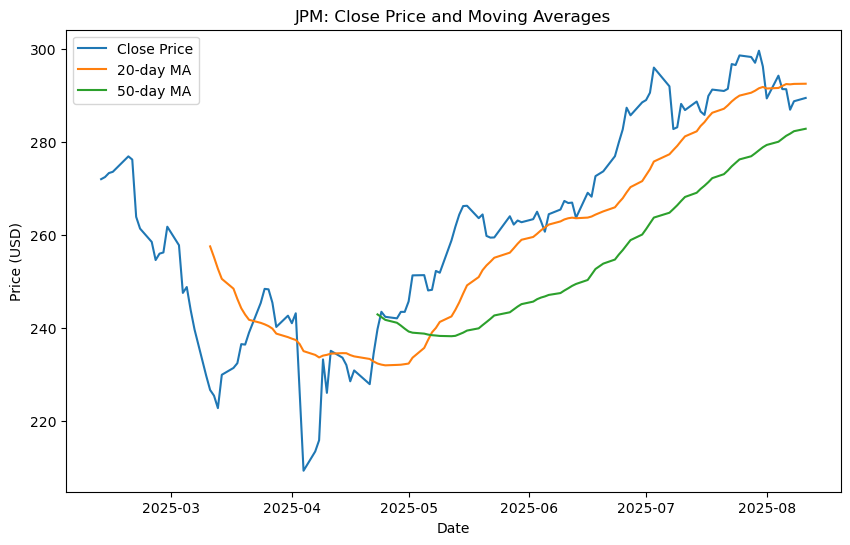

In [4]:
import matplotlib.pyplot as plt
#calculating the cose price for 6 months and moving average for all companies for 20 and 50 days 
for sym, df in data.items():
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA50'] = df['Close'].rolling(window=50).mean()
    plt.figure(figsize=(10,6))
    plt.plot(df['Close'], label='Close Price')
    plt.plot(df['MA20'], label='20-day MA')
    plt.plot(df['MA50'], label='50-day MA')
    plt.title(f"{sym}: Close Price and Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.show()


In [38]:
# Extract Close prices from the MultiIndex
close_prices = data['Close']

# Calculate daily returns
returns = close_prices.pct_change().dropna()

# Equal weights
weights = np.repeat(1/len(returns.columns), len(returns.columns))

# Portfolio returns
port_returns = returns.dot(weights)

print(port_returns.head())


Date
2025-02-12   -0.002222
2025-02-13    0.009200
2025-02-14   -0.000833
2025-02-18   -0.000005
2025-02-19    0.003746
dtype: float64


In [40]:
# 3. Define functions for VaR and CVaR

def var_cvar_param(returns, confidence=0.95):
    """
    Calculate parametric (Gaussian) VaR and CVaR at a given confidence level.
    VaR = -(mu + sigma * z_alpha), CVaR = -mu + sigma * φ(z_alpha)/alpha.
    Returns positive VaR, CVaR values (as fractions of portfolio).
    """
    mu = returns.mean()
    sigma = returns.std(ddof=0)  # population std dev
    alpha = 1 - confidence
    # z-score for the lower tail
    z = stats.norm.ppf(alpha)  
    var = -(mu + sigma * z)
    # Expected shortfall (CVaR) for a normal distribution
    cvar = -mu + sigma * stats.norm.pdf(z) / alpha
    return var, cvar

def var_cvar_historical(returns, confidence=0.95):
    """
    Calculate historical (non-parametric) VaR and CVaR at a given confidence level.
    VaR = negative of the (alpha*100)th percentile of returns.
    CVaR = average of losses beyond VaR (worst alpha fraction of returns).
    """
    alpha = 1 - confidence
    # Historical VaR (positive number)
    var = -np.percentile(returns, 100*alpha)
    # Historical CVaR: average of losses worse than VaR
    losses = -returns
    var_loss = np.percentile(losses, confidence*100)
    cvar = losses[losses >= var_loss].mean()
    return var, cvar

In [41]:
# 4. Compute daily VaR and CVaR at 95% and 99% levels
conf_levels = [0.95, 0.99]
results = {}
for conf in conf_levels:
    # Parametric
    var_p, cvar_p = var_cvar_param(port_returns, confidence=conf)
    # Historical
    var_h, cvar_h = var_cvar_historical(port_returns, confidence=conf)
    results[f'Parametric {int(conf*100)}%'] = (var_p, cvar_p)
    results[f'Historical {int(conf*100)}%'] = (var_h, cvar_h)

In [43]:
# 5. Aggregate returns to weekly and monthly, then compute VaR/CVaR
# Convert daily returns to a daily index of portfolio value (starting from 1.0)
port_value = (1 + port_returns).cumprod()
# Weekly returns (using last day of each week)
weekly_port = port_value.resample('W-FRI').last()
weekly_returns = weekly_port.pct_change().dropna()
# Monthly returns (using last day of each month)
monthly_port = port_value.resample('ME').last()
monthly_returns = monthly_port.pct_change().dropna()

for freq, ret_series in [('Weekly', weekly_returns), ('Monthly', monthly_returns)]:
    for conf in conf_levels:
        var_p, cvar_p = var_cvar_param(ret_series, confidence=conf)
        var_h, cvar_h = var_cvar_historical(ret_series, confidence=conf)
        results[f'{freq} Parametric {int(conf*100)}%'] = (var_p, cvar_p)
        results[f'{freq} Historical {int(conf*100)}%'] = (var_h, cvar_h)

In [44]:
# 6. Print out results as percentages
print("VaR and CVaR (as % of portfolio):\n")
for key, (var_val, cvar_val) in results.items():
    print(f"{key} VaR: {var_val:.2%}, CVaR: {cvar_val:.2%}")

VaR and CVaR (as % of portfolio):

Parametric 95% VaR: 2.90%, CVaR: 3.66%
Historical 95% VaR: 2.71%, CVaR: 4.06%
Parametric 99% VaR: 4.13%, CVaR: 4.75%
Historical 99% VaR: 4.84%, CVaR: 5.72%
Weekly Parametric 95% VaR: 6.02%, CVaR: 7.64%
Weekly Historical 95% VaR: 4.11%, CVaR: 6.94%
Weekly Parametric 99% VaR: 8.65%, CVaR: 9.96%
Weekly Historical 99% VaR: 8.28%, CVaR: 9.61%
Monthly Parametric 95% VaR: 6.56%, CVaR: 8.73%
Monthly Historical 95% VaR: 5.91%, CVaR: 8.00%
Monthly Parametric 99% VaR: 10.10%, CVaR: 11.86%
Monthly Historical 99% VaR: 7.59%, CVaR: 8.00%


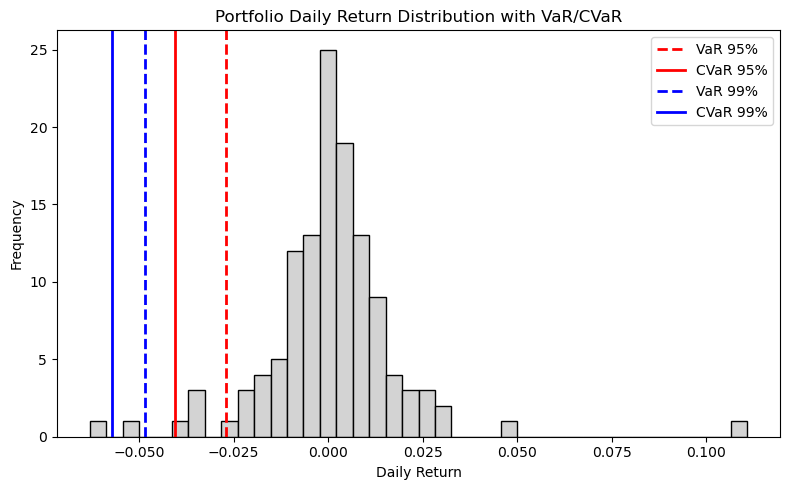

In [45]:
 
# 7. Visualization: Histogram of daily returns with VaR/CVaR lines
plt.figure(figsize=(8,5))
# Plot histogram of daily portfolio returns
plt.hist(port_returns, bins=40, color='lightgray', edgecolor='black')
# Compute the actual VaR/CVaR cutoff points for annotation
for conf, color in zip(conf_levels, ['red', 'blue']):
    alpha = 1-conf
    var_thresh = np.percentile(port_returns, 100*alpha)
    cvar_thresh = port_returns[port_returns <= var_thresh].mean()
    plt.axvline(var_thresh, color=color, linestyle='--', linewidth=2,
                label=f"VaR {int(conf*100)}%")
    plt.axvline(cvar_thresh, color=color, linestyle='-', linewidth=2,
                label=f"CVaR {int(conf*100)}%")
plt.title("Portfolio Daily Return Distribution with VaR/CVaR")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


SyntaxError: invalid character '→' (U+2192) (2836581268.py, line 7)

# Interpretation of VaR & CVaR Results

## 1. What is VaR?
Value at Risk (VaR) is the **worst expected loss** over a given time horizon at a chosen confidence level.

**Example:**
- **Parametric 95% VaR = 2.90%** → There is only a 5% chance that the portfolio will lose more than 2.90% in a single day.
- **99% VaR** is more conservative — it estimates the worst 1% of days.

 

## 2. What is CVaR?
Conditional VaR (CVaR), also called **Expected Shortfall**, is the **average loss given that the VaR threshold has been breached**.

**Example:**
- **Parametric 95% CVaR = 3.66%** → On the worst 5% of days, the average loss is 3.66% of the portfolio value.
- CVaR is **always larger** than VaR because it focuses on “deep tail” events.
 
## 3. Parametric vs Historical Methods
- **Parametric:** Assumes returns follow a normal distribution. Uses mean, standard deviation, and z-scores.
- **Historical:** Uses actual past returns without assuming normality.

**Key Differences:**
- Historical VaR/CVaR can be higher if real returns have **fat tails** (extreme moves more common than the normal model predicts).
- Example: **Historical 99% VaR = 4.84%** vs **Parametric 99% VaR = 4.13%** → History shows larger tail losses.

 

## 4. Daily vs Weekly vs Monthly
- **Daily values:** 1-day potential losses.
- **Weekly values:** 1-week holding period (compounded returns).
- **Monthly values:** 1-month holding period.

Losses **scale with time horizon**, but not perfectly proportionally because volatility and correlations change.

**Example Progression:**
- **Daily Parametric 99% VaR = 4.13%**
- **Weekly Parametric 99% VaR = 8.65%**
- **Monthly Parametric 99% VaR = 10.10%**

→ Longer holding periods increase potential drawdowns.

 
## 5. Practical Risk Management Usage
If portfolio value = **$1,000,000**:
- **Daily Historical 99% VaR (4.84%)** → ~$48,400 loss in the worst 1% of days.
- **Daily Historical 99% CVaR (5.72%)** → ~$57,200 average loss in those worst days.

**Uses:**
- Position sizing and leverage limits.
- Capital reserves estimation.
- Stop-loss policy design.
- Comparing model-based (parametric) vs actual-history-based (historical) tail risk.

 

## Conclusion
- **VaR** tells you the loss threshold you rarely expect to breach.
- **CVaR** tells you how bad it gets when you do breach it.
- Large gaps between parametric and historical values indicate that normal distribution assumptions may **underestimate real-world tail risks**.
